# Cuisine classifier

This notebook builds a simple recipe cuisine classifier using ingredients as the input features. The project focuses on five cuisines: Greek, Indian, Korean, French, and Chinese.

The goal is to show a clean end-to-end workflow for:
- loading the dataset
- cleaning ingredient text
- transforming ingredients into feature vectors
- comparing several models
- evaluating performance with cross-validation

In [22]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

DATA_PATH = Path("../data/train.json")
PUNCTUATION = "!()-[]{};:'\"\\,<>./?@#$%^&*_~"

cuisine_names = ["greek", "indian", "korean", "french", "chinese"]
model_names = [
    "logistic_regression",
    "linear_svm",
    "decision_tree",
    "k_nearest_neighbors",

    "naive_bayes",]

In [23]:
with DATA_PATH.open("r", encoding="utf-8") as recipe_file:
    recipes = json.load(recipe_file)

print(f"Loaded {len(recipes)} recipes from {DATA_PATH.name}")
print("Cuisine labels:", sorted({recipe['cuisine'] for recipe in recipes}))

Loaded 39774 recipes from train.json
Cuisine labels: ['brazilian', 'british', 'cajun_creole', 'chinese', 'filipino', 'french', 'greek', 'indian', 'irish', 'italian', 'jamaican', 'japanese', 'korean', 'mexican', 'moroccan', 'russian', 'southern_us', 'spanish', 'thai', 'vietnamese']


In [24]:
def clean_ingredient(ingredient: str) -> str:
    """Clean and normalize an ingredient string.
    
    Args:
        ingredient: Raw ingredient string from the dataset
        
    Returns:
        Cleaned ingredient: lowercase, no spaces, no punctuation
    """
    cleaned = ingredient.lower().replace(" ", "")
    for character in PUNCTUATION:
        cleaned = cleaned.replace(character, "")
    return cleaned


def gather_recipes_by_cuisine(recipe_list: list[dict], cuisine_name: str) -> pd.DataFrame:
    """Filter and clean recipes for a specific cuisine.
    
    Args:
        recipe_list: List of recipe dictionaries from the dataset
        cuisine_name: Target cuisine name to filter by
        
    Returns:
        DataFrame with columns: [id, ingredients, cuisine]
    """
    rows = []
    for recipe in recipe_list:
        if recipe.get("cuisine") != cuisine_name:
            continue

        recipe_id = recipe.get("id")
        cleaned_ingredients = [clean_ingredient(item) for item in recipe.get("ingredients", [])]
        rows.append({
            "id": recipe_id,
            "ingredients": " ".join(cleaned_ingredients),
            "cuisine": cuisine_name,
        })

    return pd.DataFrame(rows)

In [25]:
frames = [gather_recipes_by_cuisine(recipes, cuisine) for cuisine in cuisine_names]
recipe_df = pd.concat(frames, ignore_index=True)
recipe_df = shuffle(recipe_df, random_state=42).reset_index(drop=True)

print(recipe_df.head())
print(recipe_df["cuisine"].value_counts())

      id                                        ingredients  cuisine
0  14039  redchilipowder corianderseeds peas greenchilie...   indian
1  18748  groundginger molasses whippedcream groundcinna...   indian
2  24327                 salt flour tumeric oil chilipowder   indian
3  21184  bonelessskinlesschickenbreasts garlic oil gree...  chinese
4   8563  groundblackpepper lemonjuice englishcucumber f...    greek
cuisine
indian     3003
chinese    2673
french     2646
greek      1175
korean      830
Name: count, dtype: int64


In [26]:
vectorizer = CountVectorizer(binary=True)
feature_matrix = vectorizer.fit_transform(recipe_df["ingredients"])

feature_frame = pd.DataFrame(
    feature_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=recipe_df["id"],
)
feature_frame["Cuisine"] = recipe_df["cuisine"].values
feature_frame = feature_frame.reset_index(drop=True)

X = feature_frame.drop(columns=["Cuisine"]).values
y = feature_frame["Cuisine"]

print("Feature matrix shape:", X.shape)
print("Target distribution:", y.value_counts().to_dict())

Feature matrix shape: (10327, 3827)
Target distribution: {'indian': 3003, 'chinese': 2673, 'french': 2646, 'greek': 1175, 'korean': 830}


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": MultinomialNB(),
}

scoring_metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]

In [28]:
# Evaluate all models and collect results
results = []

print("\n" + "="*80)
print("RECIPE CUISINE CLASSIFIER - MODEL EVALUATION REPORT")
print("="*80)
print(f"\nDataset: {len(y)} recipes | Cuisines: {sorted(y.unique())}")
print(f"Features: {X.shape[1]} ingredients | Classes: {len(y.unique())}\n")

for model_name, model in models.items():
    scores = cross_validate(model, X, y, scoring=scoring_metrics, cv=5)
    predictions = cross_val_predict(model, X, y, cv=5)
    
    result_row = {
        "Model": model_name,
        "Accuracy": round(scores['test_accuracy'].mean(), 4),
        "Precision (weighted)": round(scores['test_precision_weighted'].mean(), 4),
        "Recall (weighted)": round(scores['test_recall_weighted'].mean(), 4),
        "F1-Score (weighted)": round(scores['test_f1_weighted'].mean(), 4),
    }
    results.append(result_row)

# Display results as a professional comparison table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Highlight best performer
best_model_idx = results_df["Accuracy"].idxmax()
best_model = results_df.loc[best_model_idx, "Model"]
best_accuracy = results_df.loc[best_model_idx, "Accuracy"]

print(f"\n{'─'*80}")
print(f"🏆 Best Model: {best_model} (Accuracy: {best_accuracy:.2%})")
print(f"{'─'*80}")


RECIPE CUISINE CLASSIFIER - MODEL EVALUATION REPORT

Dataset: 10327 recipes | Cuisines: ['chinese', 'french', 'greek', 'indian', 'korean']
Features: 3827 ingredients | Classes: 5

              Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)
Logistic Regression    0.9199                0.9202             0.9199               0.9194
         Linear SVM    0.9144                0.9142             0.9144               0.9141
      Decision Tree    0.8276                0.8269             0.8276               0.8269
k-Nearest Neighbors    0.7006                0.7002             0.7006               0.6974
        Naive Bayes    0.9089                0.9101             0.9089               0.9079

────────────────────────────────────────────────────────────────────────────────
🏆 Best Model: Logistic Regression (Accuracy: 91.99%)
────────────────────────────────────────────────────────────────────────────────


## Confusion Matrix Analysis

Visual inspection of model performance across cuisines:

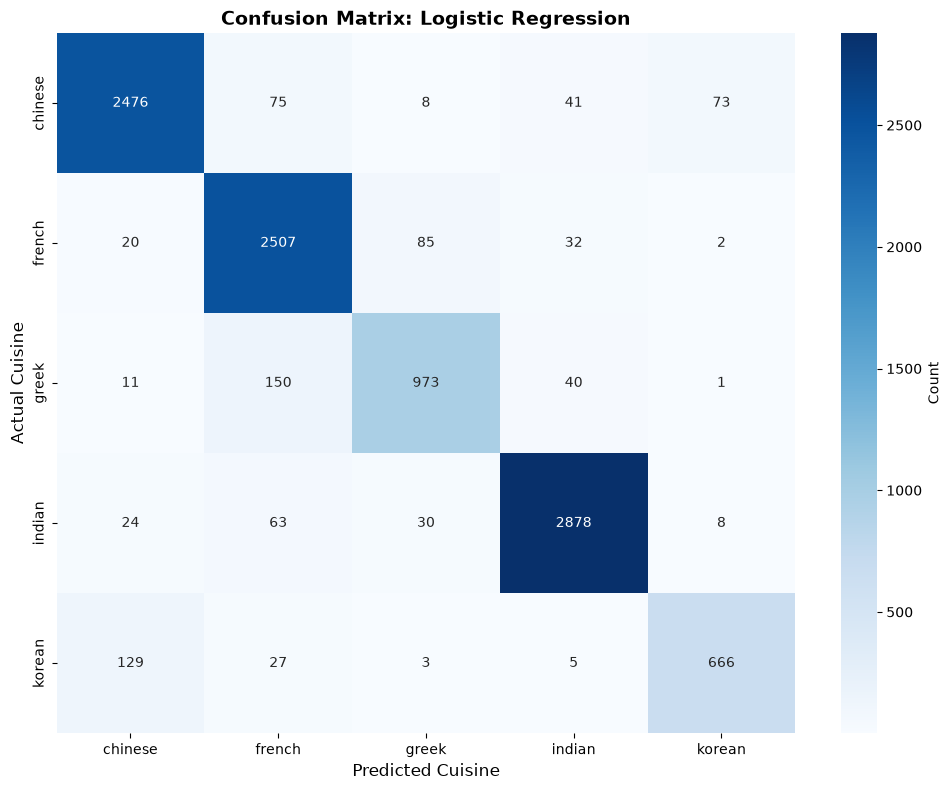


Confusion Matrix for Logistic Regression:
[[2476   75    8   41   73]
 [  20 2507   85   32    2]
 [  11  150  973   40    1]
 [  24   63   30 2878    8]
 [ 129   27    3    5  666]]


In [29]:

# Train best model and generate confusion matrix
best_model_obj = models[best_model]
final_predictions = cross_val_predict(best_model_obj, X, y, cv=5)
conf_mat = confusion_matrix(y, final_predictions, labels=sorted(y.unique()))

# Create figure with confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix: {best_model}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Cuisine', fontsize=12)
plt.xlabel('Predicted Cuisine', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix for {best_model}:")
print(conf_mat)

## Summary

This notebook is a complete, self-contained solution for recipe cuisine classification. It demonstrates:

✅ Data loading and preprocessing  
✅ Feature engineering from ingredient text  
✅ Multi-model comparison and evaluation  
✅ Results reporting  

All steps are in one readable, reproducible workflow—perfect for portfolio presentation and collaborative work. The notebook can be run end-to-end in Jupyter or VS Code.